In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt

from bridgeop.utils.trainer import TrainerModule, ScoreModel
from bridgeop.utils.data import DataFactory
from bridgeop.utils.configs import load_config
from bridgeop.diffusion.bridge import DiffusionBridge
from bridgeop.neuralop.uno import ModelFactory

In [4]:
ckpt_path = f"../ckpts/ellipsoid_brownian/"
config = load_config("ellipsoid_brownian")
    
cwd = os.getcwd()
ckpt_path = os.path.join(cwd, ckpt_path)
ckpt_path = os.path.normpath(ckpt_path)
config.train_config.dir = ckpt_path

x0 = DataFactory.create(config.data_type, config.x0_config)
xT = DataFactory.create(config.data_type, config.xT_config)

eval_shape = (48, 48, 3)
x0_eval = x0.eval(eval_shape)
xT_eval = xT.eval(eval_shape)
print(x0_eval.shape, xT_eval.shape)

(48, 48, 3) (48, 48, 3)


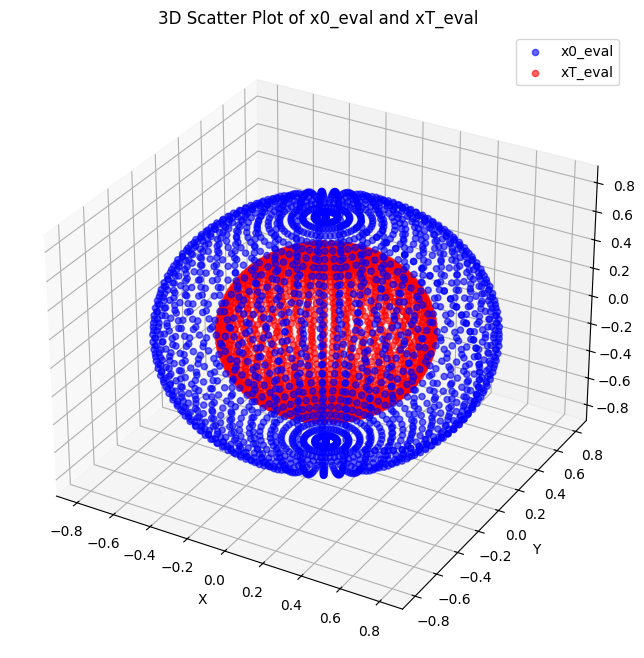

In [5]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for x0_eval
ax.scatter(x0_eval[..., 0].flatten(), x0_eval[..., 1].flatten(), x0_eval[..., 2].flatten(), 
           c='blue', label='x0_eval', alpha=0.6)

# Scatter plot for xT_eval
ax.scatter(xT_eval[..., 0].flatten(), xT_eval[..., 1].flatten(), xT_eval[..., 2].flatten(), 
           c='red', label='xT_eval', alpha=0.6)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.title('3D Scatter Plot of x0_eval and xT_eval')
plt.show()

In [6]:
db = DiffusionBridge(
    sde_type=config.sde_type,
    sde_config=config.sde_config,
)
model = ModelFactory.create(
    config.model_type,
    config.model_config,
)
trainer = TrainerModule(db, model, config.train_config)
trainer.train_model(x0=None, mode="pretrained")

Number of trainable parameters: 516,979


/home/ubuntu/miniconda3/envs/sop/lib/python3.10/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Model loaded from /home/ubuntu/projects/scoreoperator/ckpts/ellipsoid_brownian/checkpoint__step_5000


In [7]:
print(config)

data_type: ellipsoid
model_config:
  c: 32
  d_ls: !!python/tuple
  - 16
  - 32
  - 32
  d_u: 3
  d_v: 3
  modes_ls: !!python/tuple
  - 8
  - 6
model_type: CTUNO2D
sde_config:
  T: 1.0
  bm_shape: &id001 !!python/tuple
  - 16
  - 16
  - 3
  dt: 0.02
  sigma: 0.1
  x_shape: *id001
sde_type: brownian
train_config:
  batch_size: 16
  dir: /home/ubuntu/projects/scoreoperator/ckpts/ellipsoid_brownian
  log_freq: 1000
  lr: 0.001
  n_iters: 5000
  seed: 42
x0_config:
  a: 0.8
  b: 0.8
  c: 0.8
  shift_x: 0.0
  shift_y: 0.0
  shift_z: 0.0
xT_config:
  a: 0.5
  b: 0.5
  c: 0.5
  shift_x: 0.0
  shift_y: 0.0
  shift_z: 0.0



In [8]:
score_model = ScoreModel(trainer)
# score_model = lambda t, x: (x0_eval - x) / (t + 1e-8)


config.sde_config.x_shape = eval_shape
config.sde_config.bm_shape = eval_shape
eval_db = DiffusionBridge(
    sde_type=config.sde_type,
    sde_config=config.sde_config,
)

ys = eval_db.solve_reverse_bridge(
    rng_key=jax.random.PRNGKey(config.train_config.seed),
    xT=xT_eval,
    model=score_model,
)

In [9]:
print(ys.shape)
xt = ys

(50, 48, 48, 3)


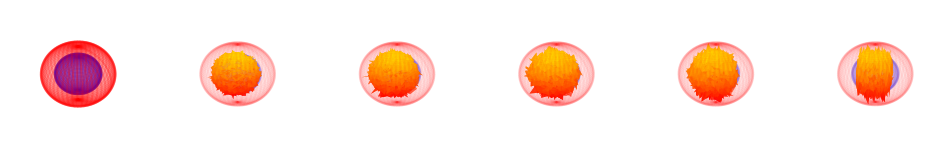

In [10]:
cmap = plt.get_cmap("autumn")
fig, axs = plt.subplots(1, 6, subplot_kw={'projection': '3d'}, figsize=(12, 4))

axs[0].plot_wireframe(x0_eval[:, :, 0], x0_eval[:, :, 1], x0_eval[:, :, 2], alpha=0.2, color="red", label=r"$x_0$")
axs[0].plot_wireframe(xT_eval[:, :, 0], xT_eval[:, :, 1], xT_eval[:, :, 2], alpha=0.2, color="blue", label=r"$x_T$")
axs[0].grid(False)
axs[0].set_axis_off()

for j in range(1, 6):
    x = xt[j*10-1]
    axs[j].plot_wireframe(x0_eval[:, :, 0], x0_eval[:, :, 1], x0_eval[:, :, 2], alpha=0.05, color="red", label=r"$x_0$")
    axs[j].plot_surface(x[:, :, 0], x[:, :, 1], x[:, :, 2], alpha=0.7, cmap=cmap, label=r"$y_t$", antialiased=True, shade=True, rstride=1, cstride=1)
    axs[j].plot_wireframe(xT_eval[:, :, 0], xT_eval[:, :, 1], xT_eval[:, :, 2], alpha=0.05, color="blue", label=r"$v$")
    axs[j].grid(False)
    axs[j].set_axis_off()
    axs[j].dist = 8
    axs[j].elev = 20
    axs[j].azim = -60